<a href="https://colab.research.google.com/github/madhavkant29/healthcare-risk-prediction-system/blob/main/Smart_Hospital_dataset_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# mounting the drive

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# importing the essential libraries

import pandas as pd
import glob

In [ ]:
# 1. Install the necessary conversion tools
!apt-get install texlive texlive-xetex texlive-latex-extra pandoc
!pip install pypandoc

# 2. Convert the notebook (Replace 'YourNotebook.ipynb' with your filename)
# Note: You must upload the .ipynb file to the Colab 'Files' sidebar first
!jupyter nbconvert --to pdf "YourNotebook.ipynb"

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
pandoc is already the newest version (2.9.2.1-3ubuntu2).
pandoc set to manually installed.
The following additional packages will be installed:
  dvisvgm fonts-droid-fallback fonts-lato fonts-lmodern fonts-noto-mono
  fonts-texgyre fonts-urw-base35 libapache-pom-java libcommons-logging-java
  libcommons-parent-java libfontbox-java libgs9 libgs9-common libidn12
  libijs-0.35 libjbig2dec0 libkpathsea6 libpdfbox-java libptexenc1 libruby3.0
  libsynctex2 libteckit0 libtexlua53 libtexluajit2 libwoff1 libzzip-0-13
  lmodern poppler-data preview-latex-style rake ruby ruby-net-telnet
  ruby-rubygems ruby-webrick ruby-xmlrpc ruby3.0 rubygems-integration t1utils
  teckit tex-common tex-gyre texlive-base texlive-binaries
  texlive-fonts-recommended texlive-latex-base texlive-latex-recommended
  texlive-pictures texlive-plain-generic tipa xfonts-encodings xfonts-utils
Suggested packages:
  fonts-noto f

In [ ]:
# path to the shortcut
path='/content/drive/My Drive/Smart_Hospital_Project_Data/'

In [ ]:
import os
import glob

# Test the path
print(f"Checking path: {path}")

# List all files in that directory
if os.path.exists(path):
    print("Folder found!")
    files = os.listdir(path)
    print(f"Files in folder: {files}")
else:
    print("Folder NOT found. Check your path or Mounting.")

all_files = glob.glob(path + "part-*.csv")
print(f"Files matching 'part-*.csv': {all_files}")

Checking path: /content/drive/My Drive/Smart_Hospital_Project_Data/
Folder found!
Files in folder: ['part1.csv', 'part5.csv', 'part3.csv', 'part4.csv', 'part2.csv']
Files matching 'part-*.csv': []


In [ ]:
# combining the distributed files content into one dataframe using pandas
all_files=glob.glob(path+"part*.csv")
hospital_data=pd.concat((pd.read_csv(f) for f in all_files),ignore_index=True)

/tmp/ipykernel_276/2943655828.py:3: DtypeWarning: Columns (8) have mixed types. Specify dtype option on import or set low_memory=False.
  hospital_data=pd.concat((pd.read_csv(f) for f in all_files),ignore_index=True)


In [ ]:
print(f"Total rows loaded: {len(hospital_data)}")
hospital_data.head()

Total rows loaded: 99343


,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,patient_token
0,Caucasian,Female,[0-10),NaN,6,25,1,1,NaN,Pediatrics-Endocrinology,...,No,No,No,No,No,No,No,No,NO,31514bd3f2425b86815df57c0538e4a0797c7f372e714e...
1,Caucasian,Female,[10-20),NaN,1,1,7,3,NaN,NaN,...,Up,No,No,No,No,No,Ch,Yes,>30,c261bc12090e7dc47169a7676a029d02a92814474461f5...
2,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,NaN,NaN,...,No,No,No,No,No,No,No,Yes,NO,3501b3103de21981906a8ee13e1811d4b32b9a03ef163e...
3,Caucasian,Male,[30-40),NaN,1,1,7,2,NaN,NaN,...,Up,No,No,No,No,No,Ch,Yes,NO,a648782b8c9b312ef504f1283df831fdeec0b17f3c64bc...
4,Caucasian,Male,[40-50),NaN,1,1,7,1,NaN,NaN,...,Steady,No,No,No,No,No,Ch,Yes,NO,0f8234448b1b89bf6e0efe2a5c053582184a91040d8306...


In [ ]:
# getting the info about the data
hospital_data.describe()

,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,number_diagnoses
count,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000,99343.000000
mean,2.030259,3.517882,5.731083,4.379332,42.906929,1.334236,15.979062,0.369246,0.198444,0.630935,7.401709
std,1.446373,5.184359,4.065029,2.968409,19.610032,1.702786,8.094909,1.265142,0.937734,1.260428,1.941013
min,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
25%,1.000000,1.000000,1.000000,2.000000,31.000000,0.000000,10.000000,0.000000,0.000000,0.000000,6.000000
50%,1.000000,1.000000,7.000000,4.000000,44.000000,1.000000,15.000000,0.000000,0.000000,0.000000,8.000000
75%,3.000000,3.000000,7.000000,6.000000,57.000000,2.000000,20.000000,0.000000,0.000000,1.000000,9.000000
max,8.000000,28.000000,25.000000,14.000000,132.000000,6.000000,81.000000,42.000000,76.000000,21.000000,16.000000


In [ ]:
# checking for null values again
missing_data=hospital_data.isnull()
# filter to show only columns that have missing values
missing_only=missing_data[missing_data> 0]

if missing_only.empty:
  print("No missing values found")
else:
  print(missing_only)


      race gender  age weight admission_type_id discharge_disposition_id  \
0      NaN    NaN  NaN   True               NaN                      NaN   
1      NaN    NaN  NaN   True               NaN                      NaN   
2      NaN    NaN  NaN   True               NaN                      NaN   
3      NaN    NaN  NaN   True               NaN                      NaN   
4      NaN    NaN  NaN   True               NaN                      NaN   
...    ...    ...  ...    ...               ...                      ...   
99338  NaN    NaN  NaN   True               NaN                      NaN   
99339  NaN    NaN  NaN   True               NaN                      NaN   
99340  NaN    NaN  NaN   True               NaN                      NaN   
99341  NaN    NaN  NaN   True               NaN                      NaN   
99342  NaN    NaN  NaN   True               NaN                      NaN   

      admission_source_id time_in_hospital payer_code medical_specialty  ...  \
0      

In [ ]:
# counting total number of rows having missing values
missing_rows_count=hospital_data.isnull().any(axis=1).sum()

total_rows=len(hospital_data)
missing_percentage=(missing_rows_count/total_rows)*100

print(f"Total rows in dataset: {total_rows}")
print(f"Rows with missing values: {missing_rows_count}")
print(f"Percentage of rows affected: {missing_percentage:.2f}%")


Total rows in dataset: 99343
Rows with missing values: 99343
Percentage of rows affected: 100.00%


In [ ]:
# calculate the number of missing values per column
missing_count=hospital_data.isnull().sum()

# calculating the percentage of missing values
missing_percentage=(missing_count/len(hospital_data))*100


# combining into a summary table

missing_report=pd.DataFrame({
    'Column Name':hospital_data.columns,
    'Missing_Count':missing_count,
    'Percentage_Missing':missing_percentage.values
})

missing_report=missing_report.sort_values(by='Percentage_Missing',ascending=False)
missing_report

,Column Name,Missing_Count,Percentage_Missing
weight,weight,96218,96.854333
max_glu_serum,max_glu_serum,94191,94.813928
A1Cresult,A1Cresult,82509,83.054669
medical_specialty,medical_specialty,48616,48.937520
payer_code,payer_code,39398,39.658557
race,race,2234,2.248774
diag_3,diag_3,1419,1.428384
diag_2,diag_2,356,0.358354
diag_1,diag_1,20,0.020132
time_in_hospital,time_in_hospital,0,0.000000


In [ ]:
# we are completely deleting the columns with more than 80 % missing values so that our final model doesn't affected by them

columns_to_drop=missing_report[missing_report['Percentage_Missing']>80]['Column Name']
hospital_data=hospital_data.drop(columns=columns_to_drop)
hospital_data.head(50)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,patient_token
0,Caucasian,Female,[0-10),6,25,1,1,NaN,Pediatrics-Endocrinology,41,...,No,No,No,No,No,No,No,No,NO,31514bd3f2425b86815df57c0538e4a0797c7f372e714e...
1,Caucasian,Female,[10-20),1,1,7,3,NaN,NaN,59,...,Up,No,No,No,No,No,Ch,Yes,>30,c261bc12090e7dc47169a7676a029d02a92814474461f5...
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,NaN,11,...,No,No,No,No,No,No,No,Yes,NO,3501b3103de21981906a8ee13e1811d4b32b9a03ef163e...
3,Caucasian,Male,[30-40),1,1,7,2,NaN,NaN,44,...,Up,No,No,No,No,No,Ch,Yes,NO,a648782b8c9b312ef504f1283df831fdeec0b17f3c64bc...
4,Caucasian,Male,[40-50),1,1,7,1,NaN,NaN,51,...,Steady,No,No,No,No,No,Ch,Yes,NO,0f8234448b1b89bf6e0efe2a5c053582184a91040d8306...
5,Caucasian,Male,[50-60),2,1,2,3,NaN,NaN,31,...,Steady,No,No,No,No,No,No,Yes,>30,28f42a298d46a677d999de071f7d4257d349bf10679917...
6,Caucasian,Male,[60-70),3,1,2,4,NaN,NaN,70,...,Steady,No,No,No,No,No,Ch,Yes,NO,09b0c47f3051f684a4ca0d090e7c580924aa8aca707e60...
7,Caucasian,Male,[70-80),1,1,7,5,NaN,NaN,73,...,No,No,No,No,No,No,No,Yes,>30,f7895b1bd7b9b03e8334e4288ff3de8401286b75c089d0...
8,Caucasian,Female,[80-90),2,1,4,13,NaN,NaN,68,...,Steady,No,No,No,No,No,Ch,Yes,NO,a66ca4396c11287a19878b31f95fd726a69a9a21f1a1aa...
9,Caucasian,Female,[90-100),3,3,4,12,NaN,InternalMedicine,33,...,Steady,No,No,No,No,No,Ch,Yes,NO,2a0d2388276b816d23dee2dc7c41f262f38da0f19508ca...


In [ ]:
hospital_data.head(50)

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,patient_token
0,Caucasian,Female,[0-10),6,25,1,1,NaN,Pediatrics-Endocrinology,41,...,No,No,No,No,No,No,No,No,NO,31514bd3f2425b86815df57c0538e4a0797c7f372e714e...
1,Caucasian,Female,[10-20),1,1,7,3,NaN,NaN,59,...,Up,No,No,No,No,No,Ch,Yes,>30,c261bc12090e7dc47169a7676a029d02a92814474461f5...
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,NaN,11,...,No,No,No,No,No,No,No,Yes,NO,3501b3103de21981906a8ee13e1811d4b32b9a03ef163e...
3,Caucasian,Male,[30-40),1,1,7,2,NaN,NaN,44,...,Up,No,No,No,No,No,Ch,Yes,NO,a648782b8c9b312ef504f1283df831fdeec0b17f3c64bc...
4,Caucasian,Male,[40-50),1,1,7,1,NaN,NaN,51,...,Steady,No,No,No,No,No,Ch,Yes,NO,0f8234448b1b89bf6e0efe2a5c053582184a91040d8306...
5,Caucasian,Male,[50-60),2,1,2,3,NaN,NaN,31,...,Steady,No,No,No,No,No,No,Yes,>30,28f42a298d46a677d999de071f7d4257d349bf10679917...
6,Caucasian,Male,[60-70),3,1,2,4,NaN,NaN,70,...,Steady,No,No,No,No,No,Ch,Yes,NO,09b0c47f3051f684a4ca0d090e7c580924aa8aca707e60...
7,Caucasian,Male,[70-80),1,1,7,5,NaN,NaN,73,...,No,No,No,No,No,No,No,Yes,>30,f7895b1bd7b9b03e8334e4288ff3de8401286b75c089d0...
8,Caucasian,Female,[80-90),2,1,4,13,NaN,NaN,68,...,Steady,No,No,No,No,No,Ch,Yes,NO,a66ca4396c11287a19878b31f95fd726a69a9a21f1a1aa...
9,Caucasian,Female,[90-100),3,3,4,12,NaN,InternalMedicine,33,...,Steady,No,No,No,No,No,Ch,Yes,NO,2a0d2388276b816d23dee2dc7c41f262f38da0f19508ca...


In [ ]:
num_columns = hospital_data.shape[1]
print(f"Number of columns in the DataFrame: {num_columns}")

Number of columns in the DataFrame: 46


In [ ]:
# filling the missnig values in medical_specialty column

hospital_data['medical_specialty'].fillna('Missing',inplace=True)

# fill 'payer_code'
hospital_data['payer_code'].fillna('Unknown',inplace=True)


/tmp/ipykernel_276/1534557664.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  hospital_data['medical_specialty'].fillna('Missing',inplace=True)
/tmp/ipykernel_276/1534557664.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inpla

In [ ]:
# import numpy as np

# 1. Fill Missing Values with '0' (representing Unknown)
hospital_data['diag_1'] = hospital_data['diag_1'].fillna('0')
hospital_data['diag_2'] = hospital_data['diag_2'].fillna('0')
hospital_data['diag_3'] = hospital_data['diag_3'].fillna('0')

# 2. Function to group 700+ ICD-9 codes into 9 easy categories
def map_diagnosis(code):
    if code == '0': return 'Other'
    try:
        # Handle codes starting with V or E (Special categories)
        if str(code).startswith(('V', 'E')):
            return 'Other'

        c = float(code)
        if 390 <= c <= 459 or c == 785: return 'Circulatory'
        elif 460 <= c <= 519 or c == 786: return 'Respiratory'
        elif 520 <= c <= 579 or c == 787: return 'Digestive'
        elif 250 <= c < 251: return 'Diabetes'
        elif 800 <= c <= 999: return 'Injury'
        elif 710 <= c <= 739: return 'Musculoskeletal'
        elif 580 <= c <= 629 or c == 788: return 'Genitourinary'
        elif 140 <= c <= 239: return 'Neoplasms'
        else: return 'Other'
    except:
        return 'Other'

# 3. Applying the mapping to all three diagnosis columns
for col in ['diag_1', 'diag_2', 'diag_3']:
    hospital_data[col] = hospital_data[col].apply(map_diagnosis)

print("Diagnosis columns successfully grouped into 9 categories!")
hospital_data[['diag_1', 'diag_2', 'diag_3']].head()

Diagnosis columns successfully grouped into 9 categories!


,diag_1,diag_2,diag_3
0,Diabetes,Other,Other
1,Other,Diabetes,Other
2,Other,Diabetes,Other
3,Other,Diabetes,Circulatory
4,Neoplasms,Neoplasms,Diabetes


In [ ]:
hospital_data.head(5)


,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted,patient_token
0,Caucasian,Female,[0-10),6,25,1,1,Unknown,Pediatrics-Endocrinology,41,...,No,No,No,No,No,No,No,No,NO,31514bd3f2425b86815df57c0538e4a0797c7f372e714e...
1,Caucasian,Female,[10-20),1,1,7,3,Unknown,Missing,59,...,Up,No,No,No,No,No,Ch,Yes,>30,c261bc12090e7dc47169a7676a029d02a92814474461f5...
2,AfricanAmerican,Female,[20-30),1,1,7,2,Unknown,Missing,11,...,No,No,No,No,No,No,No,Yes,NO,3501b3103de21981906a8ee13e1811d4b32b9a03ef163e...
3,Caucasian,Male,[30-40),1,1,7,2,Unknown,Missing,44,...,Up,No,No,No,No,No,Ch,Yes,NO,a648782b8c9b312ef504f1283df831fdeec0b17f3c64bc...
4,Caucasian,Male,[40-50),1,1,7,1,Unknown,Missing,51,...,Steady,No,No,No,No,No,Ch,Yes,NO,0f8234448b1b89bf6e0efe2a5c053582184a91040d8306...


In [ ]:
hospital_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99343 entries, 0 to 99342
Data columns (total 46 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   race                      97109 non-null  object
 1   gender                    99343 non-null  object
 2   age                       99343 non-null  object
 3   admission_type_id         99343 non-null  int64 
 4   discharge_disposition_id  99343 non-null  int64 
 5   admission_source_id       99343 non-null  int64 
 6   time_in_hospital          99343 non-null  int64 
 7   payer_code                99343 non-null  object
 8   medical_specialty         99343 non-null  object
 9   num_lab_procedures        99343 non-null  int64 
 10  num_procedures            99343 non-null  int64 
 11  num_medications           99343 non-null  int64 
 12  number_outpatient         99343 non-null  int64 
 13  number_emergency          99343 non-null  int64 
 14  number_inpatient      

In [ ]:
# finding the categories of Primary diganosis,Secondary diagnosis,tertiary
hospital_data['diag_1'].value_counts()
# This shows what % of patients have each diagnosis
#hospital_data['diag_1'].value_counts(normalize=True) * 100


,count
diag_1,
Circulatory,29681
Other,17813
Respiratory,13934
Digestive,9333
Diabetes,8661
Injury,6853
Genitourinary,5002
Musculoskeletal,4935
Neoplasms,3131


In [ ]:
#hospital_data['diag_2'].value_counts()
# This shows what % of patients have each diagnosis
hospital_data['diag_2'].value_counts(normalize=True) * 100

,proportion
diag_2,
Circulatory,31.364062
Other,26.557483
Diabetes,12.789024
Respiratory,10.458714
Genitourinary,8.200880
Digestive,4.115036
Injury,2.400773
Neoplasms,2.341383
Musculoskeletal,1.772646


In [ ]:
#hospital_data['diag_3'].value_counts()
# This shows what % of patients have each diagnosis
hospital_data['diag_3'].value_counts(normalize=True) * 100

,proportion
diag_3,
Other,30.206456
Circulatory,29.795758
Diabetes,17.091290
Respiratory,7.051327
Genitourinary,6.478564
Digestive,3.882508
Injury,1.910552
Musculoskeletal,1.910552
Neoplasms,1.672992


In [ ]:
# spliting the data for training and testing

from sklearn.model_selection import train_test_split
train_set,test_set=train_test_split(hospital_data,test_size=0.2,random_state=42)

In [ ]:
hospital_data_train=train_set.copy()
hospital_data_test=test_set.copy()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
sns.set_theme(style='whitegrid',palette='muted')
plt.rcParams['figure.figsize']=(12,8)

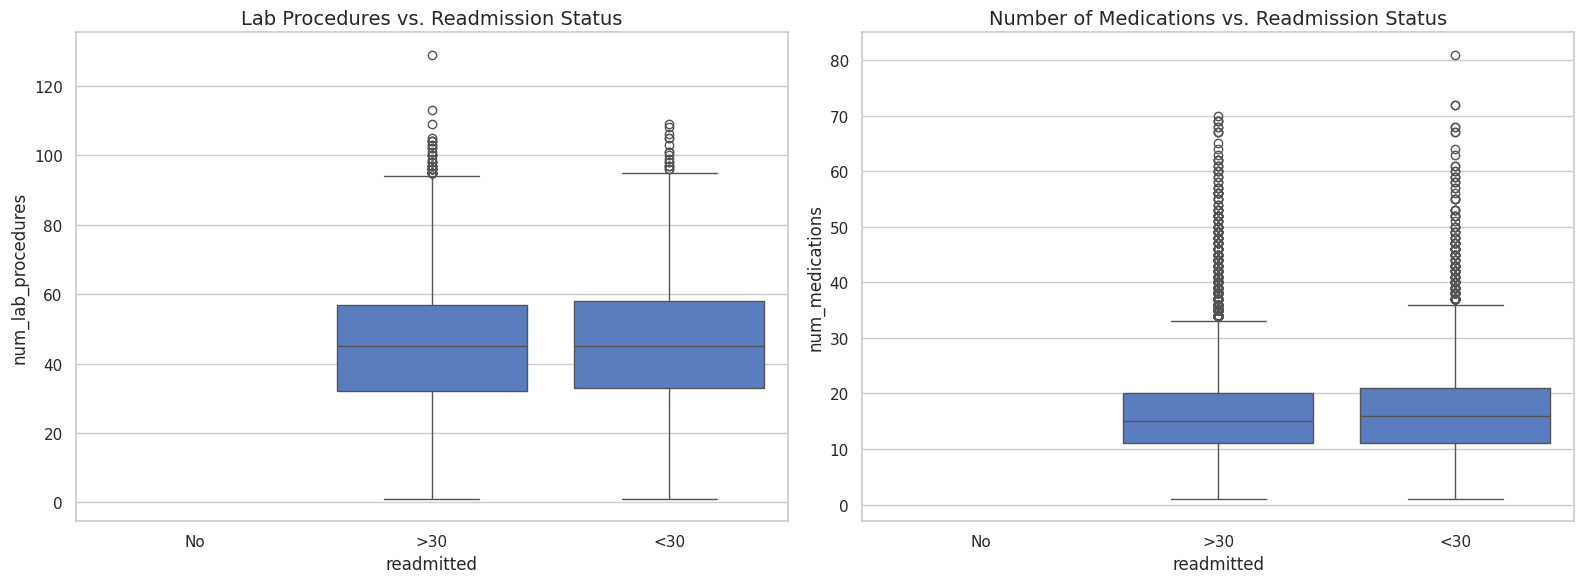

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(16,6))

sns.boxplot(data=hospital_data_train,x='readmitted',y='num_lab_procedures',ax=axes[0],order=['No','>30','<30'])
axes[0].set_title('Lab Procedures vs. Readmission Status',fontsize=14)

sns.boxplot(data=hospital_data_train, x='readmitted', y='num_medications', ax=axes[1], order=['No', '>30', '<30'])
axes[1].set_title('Number of Medications vs. Readmission Status', fontsize=14)

plt.tight_layout()
plt.show()


/tmp/ipykernel_276/512218079.py:4: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=hospital_data_train[hospital_data_train['readmitted'] == 'No'], x='num_medications', label='No Readmit', fill=True, alpha=0.3)


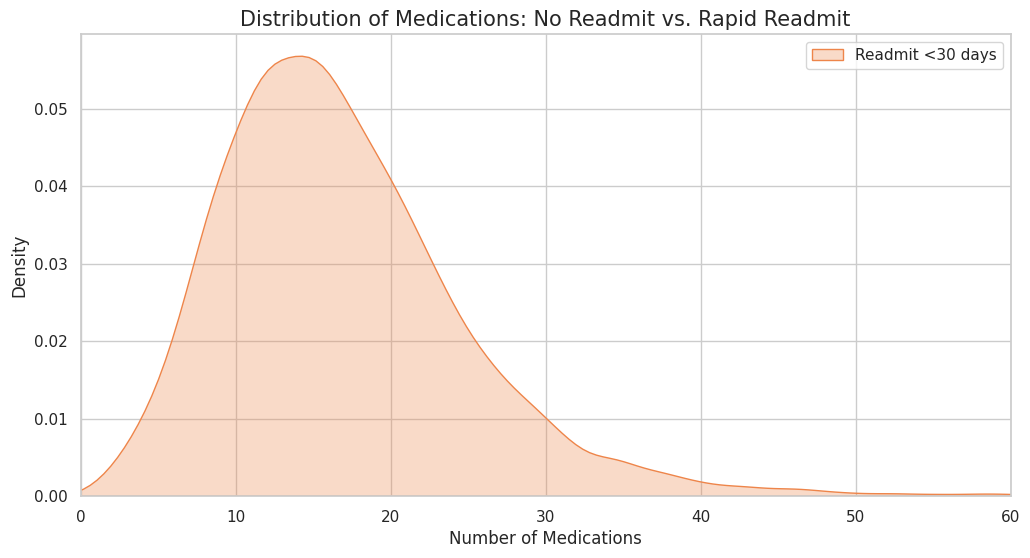

In [ ]:
plt.figure(figsize=(12, 6))

# Plotting the distribution of medications using the new variable name
sns.kdeplot(data=hospital_data_train[hospital_data_train['readmitted'] == 'No'], x='num_medications', label='No Readmit', fill=True, alpha=0.3)
sns.kdeplot(data=hospital_data_train[hospital_data_train['readmitted'] == '<30'], x='num_medications', label='Readmit <30 days', fill=True, alpha=0.3)

plt.title('Distribution of Medications: No Readmit vs. Rapid Readmit', fontsize=15)
plt.xlabel('Number of Medications')
plt.ylabel('Density')
plt.xlim(0, 60) # Clipping outliers for a "beautiful" view
plt.legend()
plt.show()

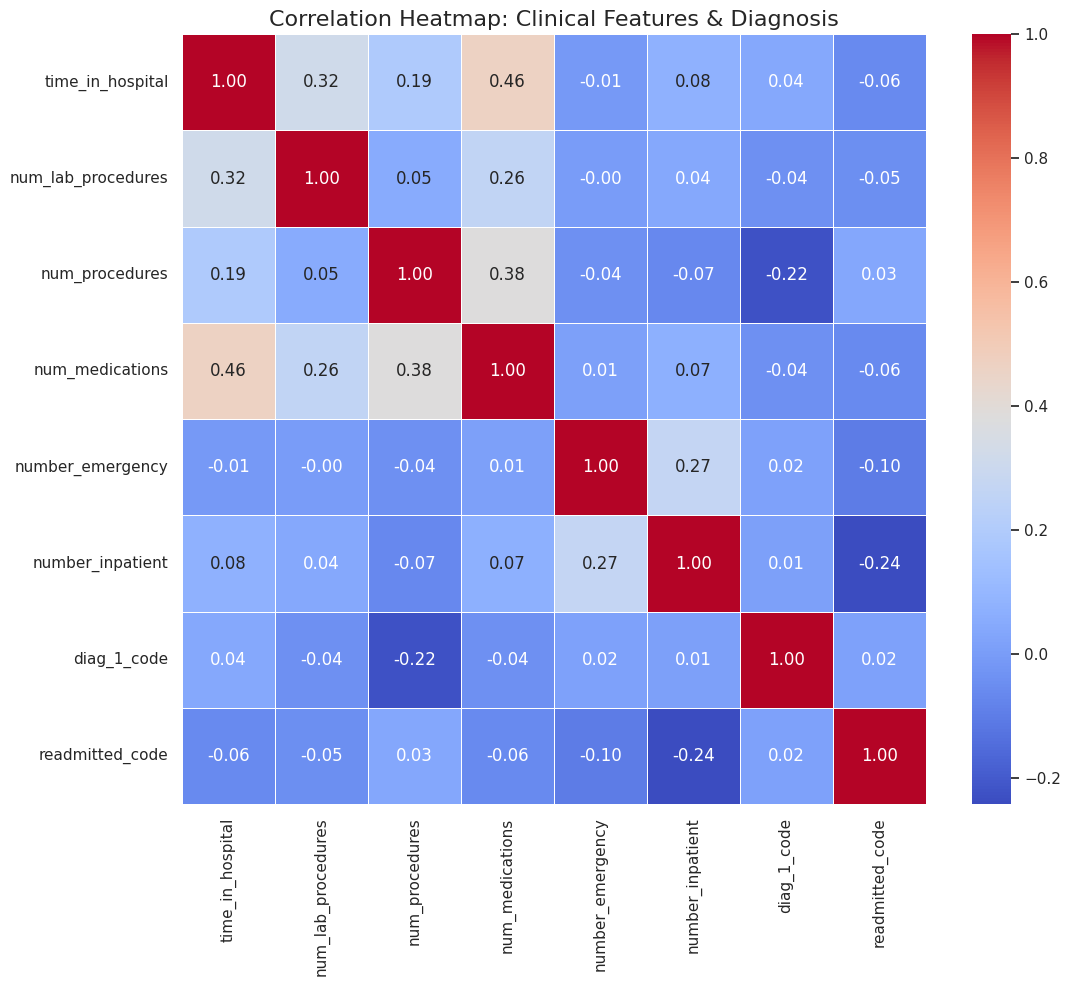

In [ ]:
# 1. Select the key numerical features
features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures',
            'num_medications', 'number_emergency', 'number_inpatient']

# 2. Create a temporary copy for the heatmap
heatmap_data = hospital_data_train[features].copy()

# 3. Add the 'Diagnosis' and 'Readmitted' as codes to see their relationship
heatmap_data['diag_1_code'] = hospital_data_train['diag_1'].astype('category').cat.codes
heatmap_data['readmitted_code'] = hospital_data_train['readmitted'].astype('category').cat.codes

# 4. Generate the Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Clinical Features & Diagnosis', fontsize=16)
plt.show()

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r - 1, k - 1))

correlation = cramers_v(hospital_data_train['diag_1'], hospital_data_train['readmitted'])
print(f"Cramér's V Correlation between Diagnosis and Readmission: {correlation:.4f}")

Cramér's V Correlation between Diagnosis and Readmission: 0.0528


In [ ]:
cols_to_check = ['diag_1', 'race', 'gender', 'age', 'medical_specialty']
results = {}

for col in cols_to_check:
    results[col] = cramers_v(hospital_data_train[col], hospital_data_train['readmitted'])

# Sort and print
for col, val in sorted(results.items(), key=lambda x: x[1], reverse=True):
    print(f"{col}: {val:.4f}")

medical_specialty: 0.0848
diag_1: 0.0528
age: 0.0431
race: 0.0236
gender: 0.0126


In [ ]:
# List of all medication columns in the dataset
medications = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# Dictionary to store the count of patients on each medicine
med_counts = {}

for med in medications:
    if med in hospital_data_train.columns:
        # Count rows where the value is NOT 'No'
        active_patients = hospital_data_train[hospital_data_train[med] != 'No'].shape[0]
        med_counts[med] = active_patients

# Convert to a sorted DataFrame for a "Leaderboard" view
common_meds = pd.DataFrame(list(med_counts.items()), columns=['Medicine', 'Patient_Count'])
common_meds = common_meds.sort_values(by='Patient_Count', ascending=False)

print("--- Top 10 Most Prescribed Medicines ---")
print(common_meds.head(10))

--- Top 10 Most Prescribed Medicines ---
               Medicine  Patient_Count
17              insulin          42294
0             metformin          15864
6             glipizide          10043
7             glyburide           8361
9          pioglitazone           5810
10        rosiglitazone           5055
4           glimepiride           4113
1           repaglinide           1191
2           nateglinide            555
18  glyburide-metformin            523


In [ ]:
# List of the most common medications in the dataset
med_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin'
]

med_results = {}
for col in med_cols:
    if col in hospital_data_train.columns:
        # We check the relationship of each drug to readmission
        med_results[col] = cramers_v(hospital_data_train[col], hospital_data_train['readmitted'])

# Sort to see the "Impactful" drugs
med_rank = pd.DataFrame(list(med_results.items()), columns=['Medication', 'Cramer_V'])
print(med_rank.sort_values(by='Cramer_V', ascending=False).head(10))

       Medication  Cramer_V
17        insulin  0.054349
0       metformin  0.028350
6       glipizide  0.015556
1     repaglinide  0.015409
11       acarbose  0.014478
10  rosiglitazone  0.013159
9    pioglitazone  0.011421
4     glimepiride  0.008507
12       miglitol  0.007687
7       glyburide  0.007076


/tmp/ipykernel_276/510622951.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2 / min(r - 1, k - 1))
/tmp/ipykernel_276/510622951.py:9: RuntimeWarning: invalid value encountered in scalar divide
  return np.sqrt(phi2 / min(r - 1, k - 1))


In [ ]:
# 1. Define the full list of potential medication columns
medications = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# 2. Identify columns with < 100 patients (where value is NOT 'No')
cols_to_remove = []
for med in medications:
    if med in hospital_data_train.columns:
        active_count = hospital_data_train[hospital_data_train[med] != 'No'].shape[0]
        if active_count < 100:
            cols_to_remove.append(med)
            print(f"Removing {med}: Only {active_count} patients.")

# 3. Drop the columns from the training set
hospital_data_train = hospital_data_train.drop(columns=cols_to_remove)

print(f"\nSuccessfully removed {len(cols_to_remove)} rare medication columns.")
print(f"Remaining columns: {len(hospital_data_train.columns)}")

Removing chlorpropamide: Only 70 patients.
Removing acetohexamide: Only 1 patients.
Removing tolbutamide: Only 15 patients.
Removing miglitol: Only 29 patients.
Removing troglitazone: Only 2 patients.
Removing tolazamide: Only 32 patients.
Removing examide: Only 0 patients.
Removing citoglipton: Only 0 patients.
Removing glipizide-metformin: Only 11 patients.
Removing glimepiride-pioglitazone: Only 1 patients.
Removing metformin-rosiglitazone: Only 1 patients.
Removing metformin-pioglitazone: Only 1 patients.

Successfully removed 12 rare medication columns.
Remaining columns: 34


In [ ]:
# Applying the same removal to your test set
hospital_data_test = hospital_data_test.drop(columns=cols_to_remove, errors='ignore')

In [ ]:
# 1. Re-calculate the importance for the remaining medicines
remaining_meds = [m for m in medications if m in hospital_data_train.columns]

final_med_ranking = {}
for med in remaining_meds:
    score = cramers_v(hospital_data_train[med], hospital_data_train['readmitted'])
    final_med_ranking[med] = score

# 2. Display the cleaned-up leaderboard
final_med_df = pd.DataFrame(list(final_med_ranking.items()), columns=['Medicine', 'Importance_Score'])
final_med_df = final_med_df.sort_values(by='Importance_Score', ascending=False)

print("--- Final Medication Importance Ranking ---")
print(final_med_df)

--- Final Medication Importance Ranking ---
               Medicine  Importance_Score
9               insulin          0.054349
0             metformin          0.028350
4             glipizide          0.015556
1           repaglinide          0.015409
8              acarbose          0.014478
7         rosiglitazone          0.013159
6          pioglitazone          0.011421
3           glimepiride          0.008507
5             glyburide          0.007076
10  glyburide-metformin          0.006574
2           nateglinide          0.005440


--- Insulin Category Summary ---
insulin
Down       9557
No        37180
Steady    23918
Up         8819
Name: readmitted, dtype: int64


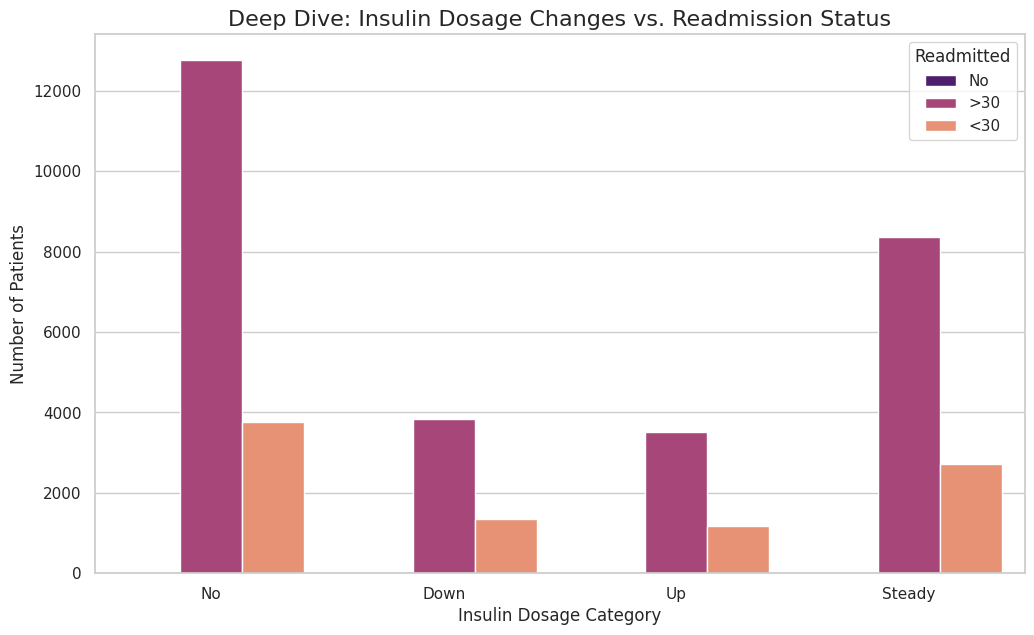

In [ ]:
# Assuming 'insulin' is the #1 predictor from your previous ranking
plt.figure(figsize=(12, 7))

# Create the count plot
sns.countplot(data=hospital_data_train, x='insulin', hue='readmitted',
              hue_order=['No', '>30', '<30'], palette='magma')

# Adding labels and styling
plt.title('Deep Dive: Insulin Dosage Changes vs. Readmission Status', fontsize=16)
plt.xlabel('Insulin Dosage Category', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.legend(title='Readmitted', loc='upper right')

# Calculate percentages for the VIVA explanation
total_per_cat = hospital_data_train.groupby('insulin')['readmitted'].count()
print("--- Insulin Category Summary ---")
print(total_per_cat)

plt.show()

In [ ]:
# 1. List of columns that are purely administrative or non-predictive
cols_to_drop = ['encounter_id', 'patient_nbr']

# Optional: Add any others your team decided were "noise"
# e.g., cols_to_drop.extend(['payer_code'])

# 2. Apply the drop to both sets
hospital_data_train = hospital_data_train.drop(columns=cols_to_drop, errors='ignore')
hospital_data_test = hospital_data_test.drop(columns=cols_to_drop, errors='ignore')

print(f"Removed {cols_to_drop}. Data is now lean and ready for Encoding.")

Removed ['encounter_id', 'patient_nbr']. Data is now lean and ready for Encoding.


/tmp/ipykernel_276/1793702267.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df, x='Correlation', y='Feature', palette='coolwarm')


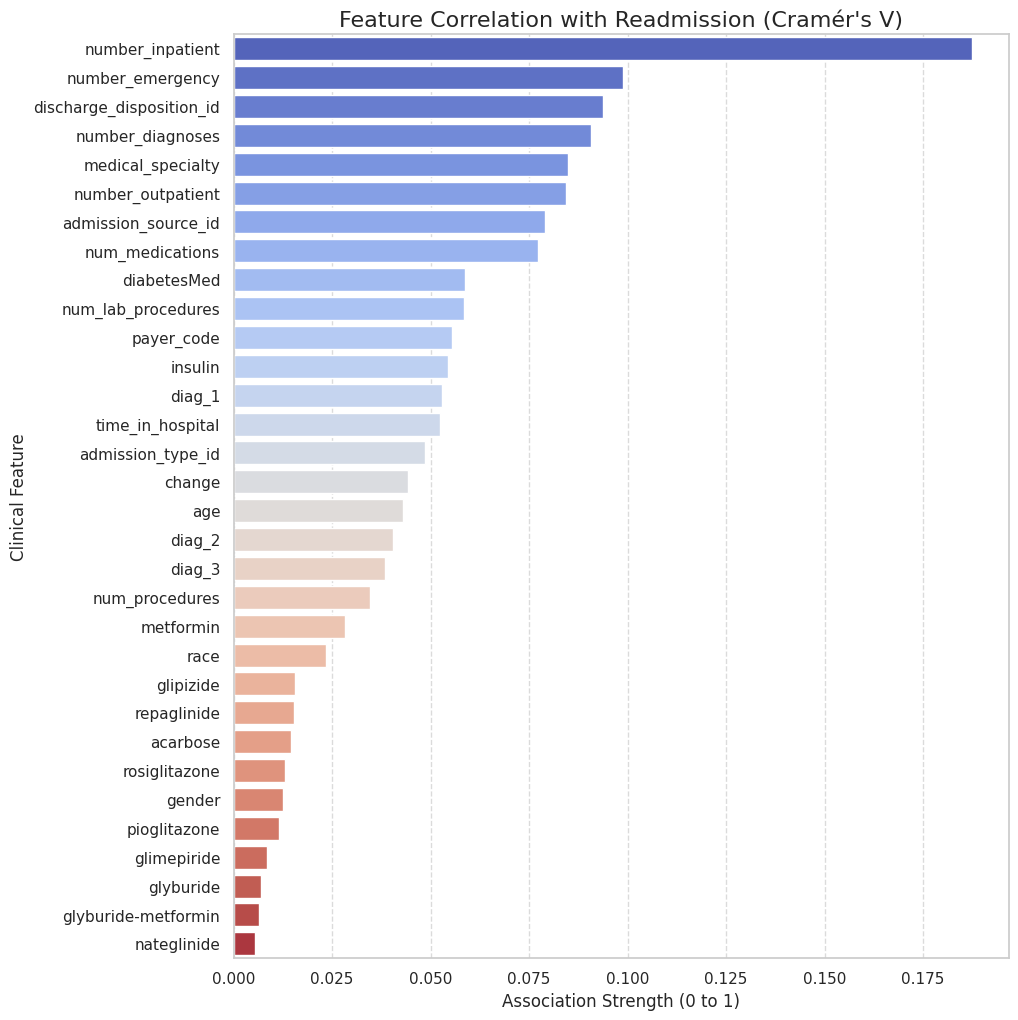

--- Top 15 Most Important Features ---
                     Feature  Correlation
14          number_inpatient     0.187295
13          number_emergency     0.098793
4   discharge_disposition_id     0.093835
18          number_diagnoses     0.090674
8          medical_specialty     0.084829
12         number_outpatient     0.084450
5        admission_source_id     0.079122
11           num_medications     0.077267
31               diabetesMed     0.058631
9         num_lab_procedures     0.058392
7                 payer_code     0.055320
28                   insulin     0.054349
15                    diag_1     0.052847
6           time_in_hospital     0.052325
3          admission_type_id     0.048663


In [ ]:
# 1. Define Cramér's V function
def calculate_cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    return np.sqrt(phi2 / min(r - 1, k - 1))

# 2. Identify all columns except the target and ID
all_remaining_cols = [c for c in hospital_data_train.columns if c not in ['readmitted', 'patient_token']]

# 3. Calculate correlation for every column
correlations = []
for col in all_remaining_cols:
    score = calculate_cramers_v(hospital_data_train[col], hospital_data_train['readmitted'])
    correlations.append({'Feature': col, 'Correlation': score})

# 4. Create a DataFrame and Sort
corr_df = pd.DataFrame(correlations).sort_values(by='Correlation', ascending=False)

# 5. Visualize the "Beautiful" Correlation Bar Chart
plt.figure(figsize=(10, 12))
sns.barplot(data=corr_df, x='Correlation', y='Feature', palette='coolwarm')
plt.title('Feature Correlation with Readmission (Cramér\'s V)', fontsize=16)
plt.xlabel('Association Strength (0 to 1)', fontsize=12)
plt.ylabel('Clinical Feature', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# 6. Print the Top 15 for quick reference
print("--- Top 15 Most Important Features ---")
print(corr_df.head(15))

/tmp/ipykernel_276/1982871618.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(20), x='Importance', y='Feature', palette='viridis')


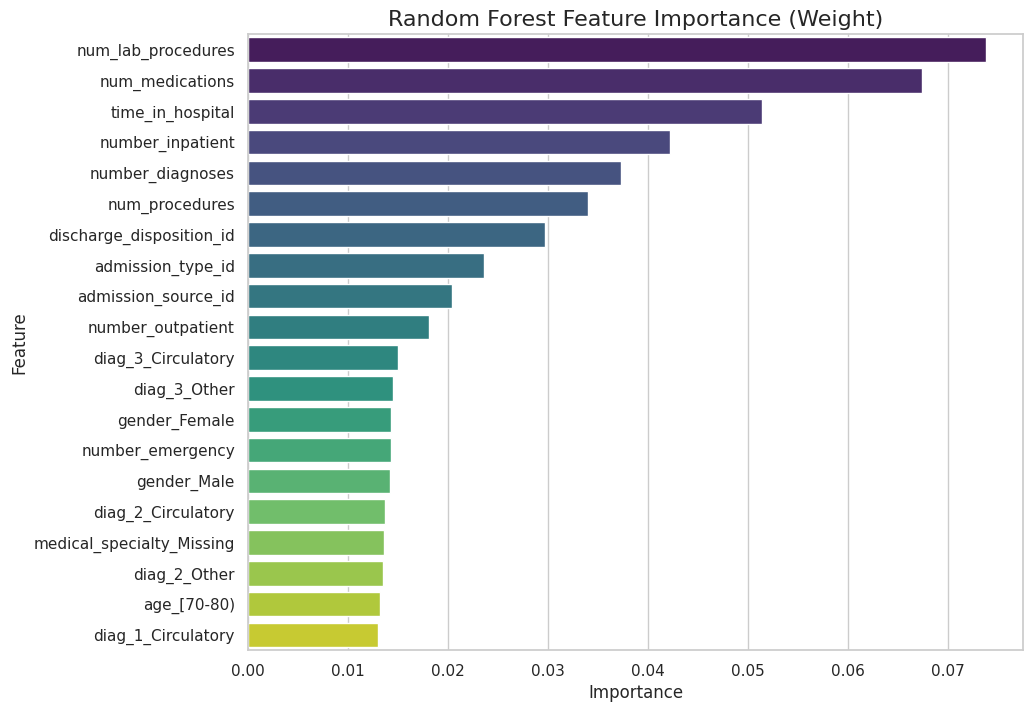

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare data (Need numeric for the Forest)
X_temp = pd.get_dummies(hospital_data_train.drop(columns=['readmitted', 'patient_token']))
y_temp = hospital_data_train['readmitted']

# 2. Train a fast Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_temp, y_temp)

# 3. Extract Importances
importances = pd.DataFrame({
    'Feature': X_temp.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Plot the Top 20
plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Feature Importance (Weight)', fontsize=16)
plt.show()

In [ ]:
# 1. List of all potential medication columns
medications = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide',
    'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose',
    'miglitol', 'troglitazone', 'tolazamide', 'examide',
    'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone'
]

# 2. Identify columns with < 1000 active patients
meds_to_remove = []
for med in medications:
    if med in hospital_data_train.columns:
        # Count patients who are actually taking the drug (Steady, Up, or Down)
        active_count = hospital_data_train[hospital_data_train[med] != 'No'].shape[0]
        if active_count < 1000:
            meds_to_remove.append(med)
            print(f"Dropping {med}: Only {active_count} patients.")

# 3. Apply the drop
hospital_data_train = hospital_data_train.drop(columns=meds_to_remove)
hospital_data_test = hospital_data_test.drop(columns=meds_to_remove)

print(f"\nClean-up Complete. Removed {len(meds_to_remove)} low-impact medications.")

Dropping nateglinide: Only 555 patients.
Dropping acarbose: Only 241 patients.
Dropping glyburide-metformin: Only 523 patients.

Clean-up Complete. Removed 3 low-impact medications.


In [ ]:
import pandas as pd

# 1. Focus on the most important numerical columns from your ss.png
numerical_cols = ['num_lab_procedures', 'num_medications', 'time_in_hospital', 'num_procedures']

def cap_outliers_iqr(df, columns):
    df_capped = df.copy()
    for col in columns:
        Q1 = df_capped[col].quantile(0.25)
        Q3 = df_capped[col].quantile(0.75)
        IQR = Q3 - Q1

        lower_fence = Q1 - 1.5 * IQR
        upper_fence = Q3 + 1.5 * IQR

        # Apply the Cap:
        # Values > Upper Fence become Upper Fence
        # Values < Lower Fence become Lower Fence
        df_capped[col] = df_capped[col].clip(lower=lower_fence, upper=upper_fence)

        print(f"Capped outliers in {col} at: {upper_fence}")

    return df_capped

# 2. Apply to both Train and Test to keep them consistent
hospital_data_train = cap_outliers_iqr(hospital_data_train, numerical_cols)
hospital_data_test = cap_outliers_iqr(hospital_data_test, numerical_cols)

Capped outliers in num_lab_procedures at: 96.0
Capped outliers in num_medications at: 35.0
Capped outliers in time_in_hospital at: 12.0
Capped outliers in num_procedures at: 5.0
Capped outliers in num_lab_procedures at: 94.5
Capped outliers in num_medications at: 35.0
Capped outliers in time_in_hospital at: 12.0
Capped outliers in num_procedures at: 5.0


/tmp/ipykernel_276/3741248532.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances.head(20), x='Importance', y='Feature', palette='viridis')


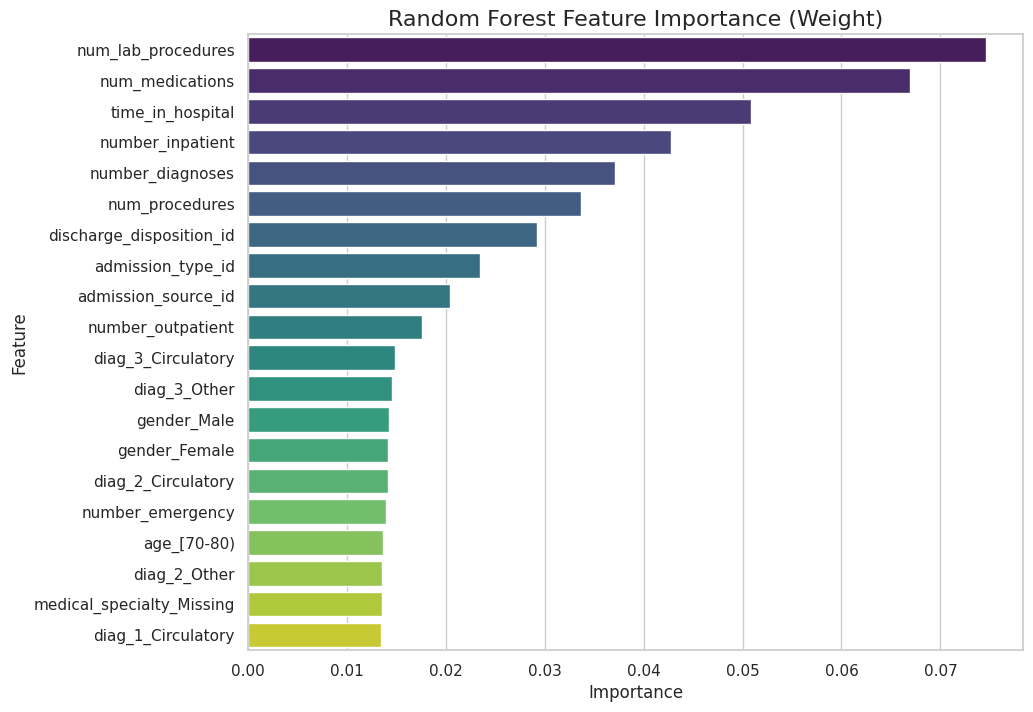

In [ ]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
import matplotlib.pyplot as plt

# 1. Prepare data (Need numeric for the Forest)
X_temp = pd.get_dummies(hospital_data_train.drop(columns=['readmitted', 'patient_token']))
y_temp = hospital_data_train['readmitted']

# 2. Train a fast Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_temp, y_temp)

# 3. Extract Importances
importances = pd.DataFrame({
    'Feature': X_temp.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 4. Plot the Top 20
plt.figure(figsize=(10, 8))
sns.barplot(data=importances.head(20), x='Importance', y='Feature', palette='viridis')
plt.title('Random Forest Feature Importance (Weight)', fontsize=16)
plt.show()


In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from imblearn.over_sampling import SMOTE
from collections import Counter

# 1. Combine Train and Test briefly for identical One-Hot Encoding
hospital_data_train['is_train'] = 1
hospital_data_test['is_train'] = 0
combined_df = pd.concat([hospital_data_train, hospital_data_test], axis=0)

# 2. Preprocessing (Drop ID, Encode, and Scale)
target = combined_df['readmitted']
train_flags = combined_df['is_train']
X_combined = combined_df.drop(columns=['readmitted', 'is_train', 'patient_token'], errors='ignore')

X_encoded = pd.get_dummies(X_combined)
scaler = MinMaxScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_encoded), columns=X_encoded.columns)

# 3. Split back into Train and Test
X_train = X_scaled[train_flags.values == 1]
y_train = target[train_flags.values == 1]

X_test = X_scaled[train_flags.values == 0]
y_test = target[train_flags.values == 0]

# 4. Apply SMOTE to the Training Set ONLY
print(f"Original training balance: {Counter(y_train)}")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)
print(f"Balanced training balance: {Counter(y_train_balanced)}")

# 5. Re-combine for final CSV export
final_train_csv = X_train_balanced.copy()
final_train_csv['readmitted'] = y_train_balanced

final_test_csv = X_test.copy()
final_test_csv['readmitted'] = y_test.values

# 6. Export to CSV
final_train_csv.to_csv('hospital_train_BALANCED.csv', index=False)
final_test_csv.to_csv('hospital_test_REAL.csv', index=False)

print("\nFiles are ready for download in the sidebar!")

Original training balance: Counter({'NO': 41992, '>30': 28468, '<30': 9014})
Balanced training balance: Counter({'>30': 41992, '<30': 41992, 'NO': 41992})

Files are ready for download in the sidebar!


/tmp/ipykernel_276/716844995.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_plot, palette='viridis')
/tmp/ipykernel_276/716844995.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_test_plot, palette='magma')


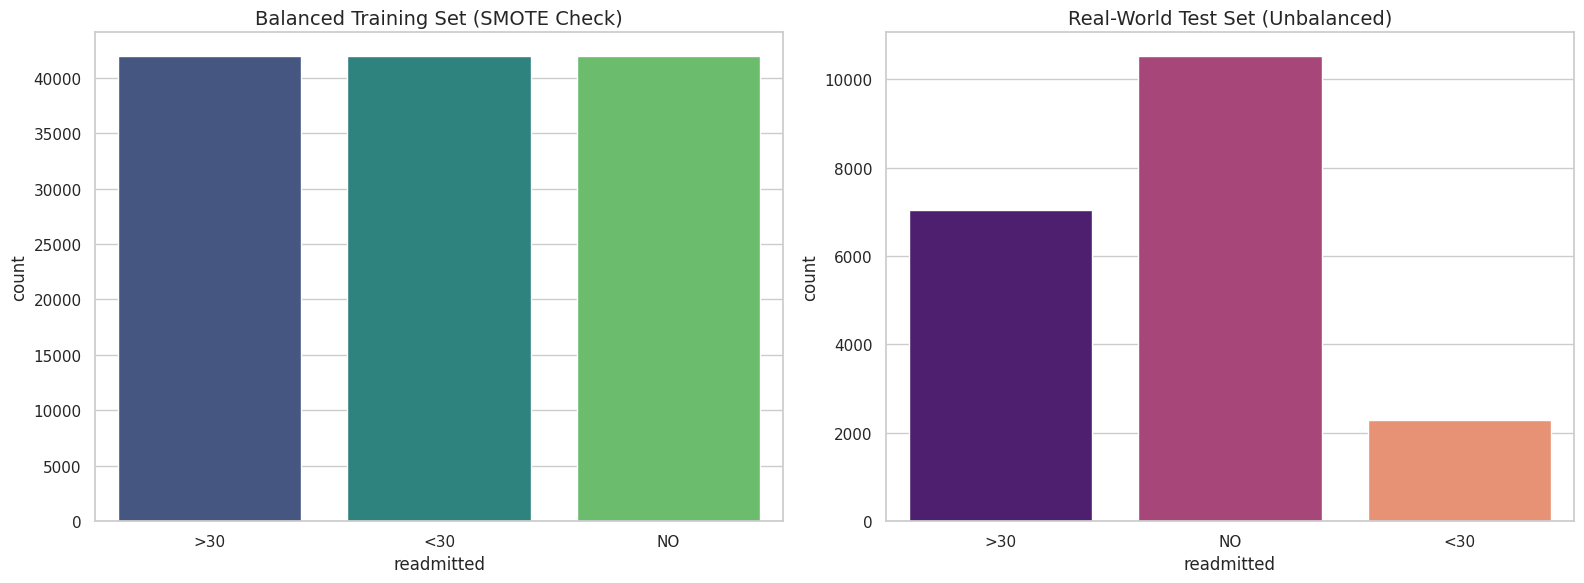

--- Final Distribution Check ---
Training Set Counts:
 readmitted
>30    41992
<30    41992
NO     41992
Name: count, dtype: int64

Test Set Counts:
 readmitted
NO     10535
>30     7034
<30     2300
Name: count, dtype: int64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Convert targets to pandas Series for easier plotting
y_train_plot = pd.Series(y_train_balanced)
y_test_plot = pd.Series(y_test)

# 2. Create the figure
plt.figure(figsize=(16, 6))

# Subplot 1: Balanced Training Set
plt.subplot(1, 2, 1)
# We remove the fixed 'order' to see exactly what SMOTE produced
sns.countplot(x=y_train_plot, palette='viridis')
plt.title('Balanced Training Set (SMOTE Check)', fontsize=14)
plt.xticks(rotation=0)

# Subplot 2: Real-World Test Set
plt.subplot(1, 2, 2)
sns.countplot(x=y_test_plot, palette='magma')
plt.title('Real-World Test Set (Unbalanced)', fontsize=14)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# Double check the actual values in the console
print("--- Final Distribution Check ---")
print("Training Set Counts:\n", y_train_plot.value_counts())
print("\nTest Set Counts:\n", y_test_plot.value_counts())

In [ ]:
# 1. Save your notebook (Ctrl+S) before running this!
from google.colab import files

# 2. This finds your notebook file and converts it to HTML
# It assumes you've uploaded the .ipynb to the sidebar as discussed earlier
import os
notebook_file = [f for f in os.listdir('.') if f.endswith('.ipynb')][0]

!jupyter nbconvert --to html "{notebook_file}"

# 3. Automatically trigger the download of the new HTML file
html_file = notebook_file.replace(".ipynb", ".html")
files.download(html_file)

[NbConvertApp] Converting notebook Smart_Hospital_Main_Pipeline.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 1242919 bytes to Smart_Hospital_Main_Pipeline.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# 1. Ensure your .ipynb is in the sidebar (drag it there now if not)
import os

# 2. Get the filename
notebook_file = [f for f in os.listdir('.') if f.endswith('.ipynb')][0]

# 3. Create a custom CSS file to force wrapping
with open("custom_style.css", "w") as f:
    f.write("""
    pre {
        white-space: pre-wrap !important;
        word-break: break-all !important;
    }
    code {
        white-space: pre-wrap !important;
    }
    """)

# 4. Convert to HTML using the custom style
!jupyter nbconvert --to html "{notebook_file}" --template full --theme light

print(f"Done! Now open the {notebook_file.replace('.ipynb', '.html')} file in your browser and Print to PDF.")

[NbConvertApp] Converting notebook Smart_Hospital_Main_Pipeline.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 1220786 bytes to Smart_Hospital_Main_Pipeline.html
Done! Now open the Smart_Hospital_Main_Pipeline.html file in your browser and Print to PDF.


In [ ]:
final_train_csv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125976 entries, 0 to 125975
Columns: 184 entries, admission_type_id to readmitted
dtypes: float64(183), object(1)
memory usage: 176.8+ MB
